In [1]:
import pandas as pd

In [4]:
df = pd.read_excel('https://storage.googleapis.com/dqlab-dataset/credit_scoring_dqlab.xlsx')

df.drop(['kode_kontrak'], axis=1, inplace=True)
df.drop(['rata_rata_overdue'], axis=1, inplace=True)

In [6]:
df.loc[(df['kpr_aktif']=='YA'), 'kpr_aktif'] = "True"
df.loc[(df['kpr_aktif']=='TIDAK'), 'kpr_aktif'] = "False"
df['kpr_aktif'] = df['kpr_aktif'].astype('bool')

In [7]:
feature_cols = ['pendapatan_setahun_juta', 'kpr_aktif', 'durasi_pinjaman_bulan', 'jumlah_tanggungan']

In [8]:
X = df[feature_cols]
y = df['risk_rating']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

In [10]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [11]:
#Melakukan labeling pada Decision Tree
feature_names = X.columns
labels = list(y.unique())
labels.sort()
labels = [str(x) for x in labels]

In [12]:
#Visualisasi Decision Tree Classifier menggunakan library 'tree' impor paket yang dibutuhkan
from sklearn import tree
import matplotlib.pyplot as plt

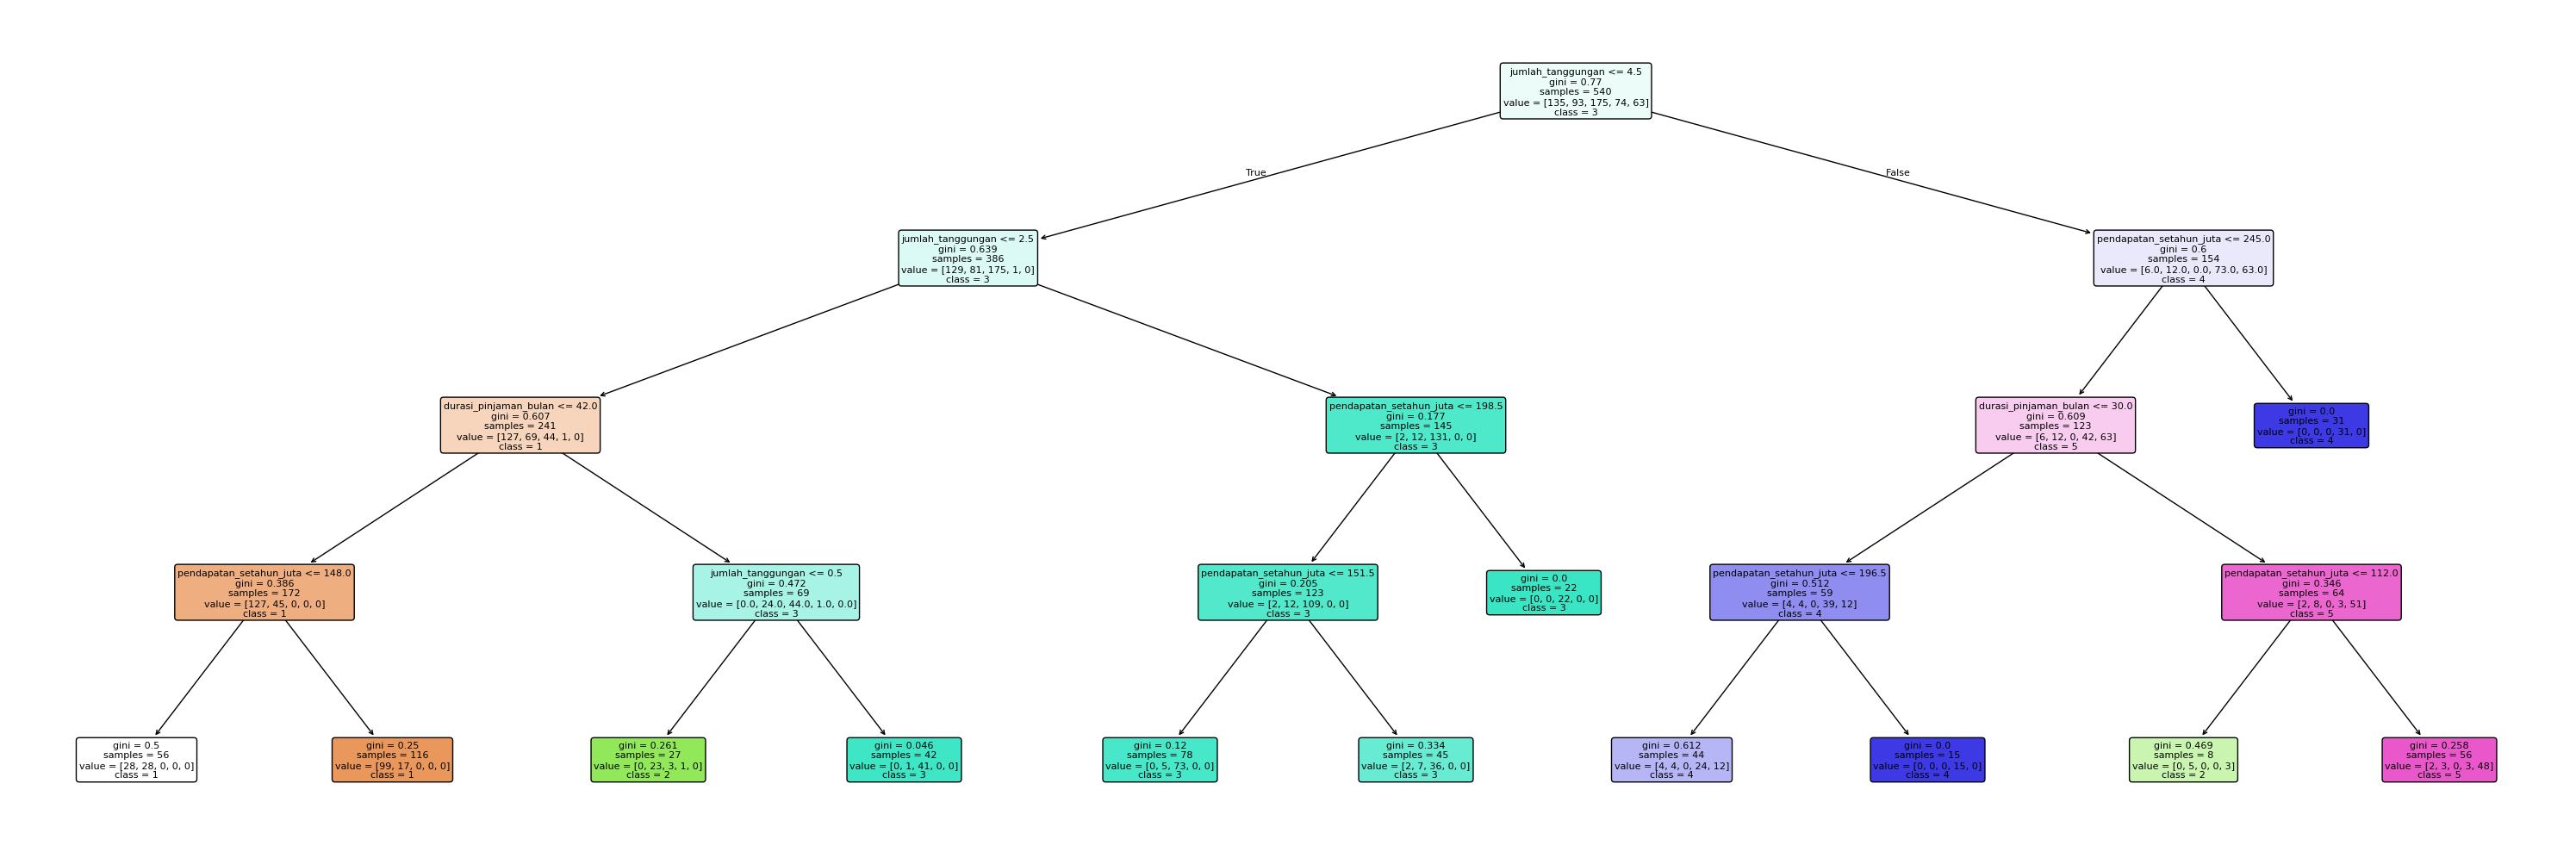

In [13]:
#plot gambar dan atur warna latar
plt.figure(figsize=(30,10), facecolor ='white')

#Buat diagram pohon
tree.plot_tree(clf, feature_names=feature_names, class_names=labels, rounded=True, filled=True, fontsize=8)

#Tampilkan gambar
plt.tight_layout()
plt.show()

In [14]:
#Visualisasi Decision Tree menggunakan text
#import relevant functions
from sklearn.tree import export_text
 
#export the decision rules
tree_rules = export_text(clf, feature_names=list(X.columns))
 
#print the result
print(tree_rules)

|--- jumlah_tanggungan <= 4.50
|   |--- jumlah_tanggungan <= 2.50
|   |   |--- durasi_pinjaman_bulan <= 42.00
|   |   |   |--- pendapatan_setahun_juta <= 148.00
|   |   |   |   |--- class: 1
|   |   |   |--- pendapatan_setahun_juta >  148.00
|   |   |   |   |--- class: 1
|   |   |--- durasi_pinjaman_bulan >  42.00
|   |   |   |--- jumlah_tanggungan <= 0.50
|   |   |   |   |--- class: 2
|   |   |   |--- jumlah_tanggungan >  0.50
|   |   |   |   |--- class: 3
|   |--- jumlah_tanggungan >  2.50
|   |   |--- pendapatan_setahun_juta <= 198.50
|   |   |   |--- pendapatan_setahun_juta <= 151.50
|   |   |   |   |--- class: 3
|   |   |   |--- pendapatan_setahun_juta >  151.50
|   |   |   |   |--- class: 3
|   |   |--- pendapatan_setahun_juta >  198.50
|   |   |   |--- class: 3
|--- jumlah_tanggungan >  4.50
|   |--- pendapatan_setahun_juta <= 245.00
|   |   |--- durasi_pinjaman_bulan <= 30.00
|   |   |   |--- pendapatan_setahun_juta <= 196.50
|   |   |   |   |--- class: 4
|   |   |   |--- penda

In [18]:
#Lakukan prediksi dataset training menggunakan model yang telah dibangun
from sklearn import metrics 
train_pred = clf.predict(X_train)
train_accuracy = metrics.accuracy_score(y_train, train_pred)
print('Akurasi training dataset:', train_accuracy)

Akurasi training dataset: 0.8240740740740741


In [17]:
#Lakukan prediksi dataset testing menggunakan model yang telah dibangun
test_pred = clf.predict(X_test)
test_accuracy = metrics.accuracy_score(y_test, test_pred)
print('Akurasi testing dataset :', test_accuracy)

Akurasi testing dataset : 0.7805555555555556


In [19]:
#Impor fungsi GridSearchCV
from sklearn.model_selection import GridSearchCV

In [20]:
#Tentukan nilai parameter max_depth yang akan diuji
tuned_parameters = [{'max_depth': [1,2,3,4,5,6,7,8,9,10]}]

In [21]:
#Tentukan kriteria penilaian menggunakan nilai F1
print('\nTuning hyperparameters untuk F1-score\n')

clf = GridSearchCV(DecisionTreeClassifier(), tuned_parameters, scoring='f1_macro')
clf.fit(X_train, y_train)


Tuning hyperparameters untuk F1-score



,estimator,DecisionTreeClassifier()
,param_grid,"[{'max_depth': [1, 2, ...]}]"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [22]:
print('Hasil nilai uji saat melakukan tuning:')
means = clf.cv_results_['mean_test_score']
stds = clf.cv_results_['std_test_score']
for mean, std, params in zip(means, stds, clf.cv_results_['params']):
	print(f'{mean:0.3f} (+/-{std*2:0.03f}) for {params}')
	
#Parameter terbaik yang ditemukan
print('\nParameter terbaik yang ditemukan:')
print(clf.best_params_)

Hasil nilai uji saat melakukan tuning:
0.253 (+/-0.006) for {'max_depth': 1}
0.539 (+/-0.025) for {'max_depth': 2}
0.676 (+/-0.053) for {'max_depth': 3}
0.745 (+/-0.112) for {'max_depth': 4}
0.756 (+/-0.092) for {'max_depth': 5}
0.767 (+/-0.123) for {'max_depth': 6}
0.776 (+/-0.109) for {'max_depth': 7}
0.758 (+/-0.117) for {'max_depth': 8}
0.734 (+/-0.147) for {'max_depth': 9}
0.722 (+/-0.087) for {'max_depth': 10}

Parameter terbaik yang ditemukan:
{'max_depth': 7}


In [23]:
#Model dengan parameter terbaik yang ditemukan
best_model = clf.best_estimator_

In [24]:
#Lakukan prediksi dataset training dan dataset testing menggunakan model dengan parameter terbaik
train_pred = best_model.predict(X_train)
train_accuracy = metrics.accuracy_score(y_train, train_pred)
test_pred = best_model.predict(X_test)
test_accuracy = metrics.accuracy_score(y_test, test_pred)

print('\nAkurasi training dataset:', train_accuracy)
print('Akurasi testing dataset :', test_accuracy)


Akurasi training dataset: 0.8777777777777778
Akurasi testing dataset : 0.7722222222222223
